In [2]:
import scipy.stats as sci
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [3]:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

# BS

In [4]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))*S - sci.norm.cdf(d2(S, K, T, r, sigma))*K*np.exp(-r*T)

In [5]:
call_price(100, 100, 1, 0.05, 0.2)

np.float64(10.450583572185572)

In [6]:
def put_price(S, K, T, r, sigma): 
    return - sci.norm.cdf(-d1(S, K, T, r, sigma))*S + sci.norm.cdf(-d2(S, K, T, r, sigma))*K*np.exp(-r*T)

In [7]:
put_price(100, 100, 1, 0.05, 0.2)

np.float64(5.573526022256971)

Call-put parity - holding a call and investing is exactly equal to holding a put and the stock

In [8]:
def delta_call(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))

def delta_put(S, K, T, r, sigma):
    return - sci.norm.cdf(-d2(S, K, T, r, sigma))

In [9]:
delta_call(100, 50, 1, 0.05, 0.2)

np.float64(0.9999321111667006)

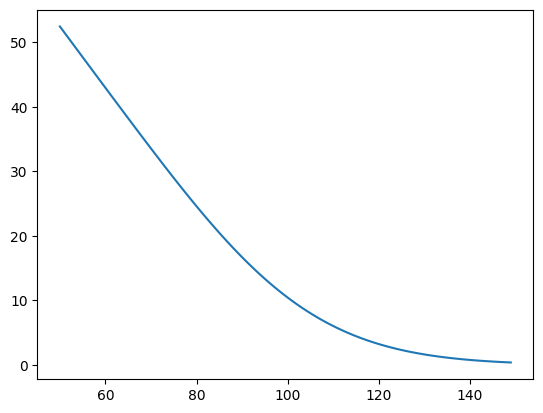

In [10]:
Ks = np.arange(50, 150, 1)
plt.plot(Ks, call_price(S, Ks, T, r, sigma))

# Monte Carlo

In [11]:
def price_at_strike(S, K, T, r, sigma, noise):
    return S * np.exp((r - sigma**2 / 2)*T + sigma * np.sqrt(T)*noise)

In [12]:
strike_prices = price_at_strike(S, K, T, r, sigma, np.random.randn(10000000))

In [13]:
payouts = list(map(lambda x: max(x - K, 0), strike_prices))

In [14]:
np.mean(payouts) * np.exp(-r*T)

np.float64(10.448622011023781)